# 机器学习与深度学习

MLP、激活函数、反向传播、批处理、正则化、CNN、RNN、LSTM、seq2seq、注意力、Transformer、过拟合与欠拟合、数据预处理、模型评估、损失函数、决策树、随机森林、集成学习、XGBoost、GBDT、K-Means。

每节包含：

1. 关键公式与定义
2. 优缺点
3. 使用 `scikit-learn` 示例数据的可复现可视化

图形采用可发表风格：统一字体、矢量与位图导出（SVG / PDF / TIFF）。

## 0. 环境配置与Nature风格绘图函数

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=FutureWarning, module=r"sklearn\..*")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

%matplotlib inline
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import pandas as pd

from sklearn.datasets import (
    load_breast_cancer,
    load_iris,
    load_digits,
    make_blobs,
    make_classification,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_squared_error,
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
import matplotlib.font_manager as fm

RNG = np.random.RandomState(42)
rng = RNG
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def _pick_chinese_font():
    preferred = [
        "Microsoft YaHei",
        "PingFang SC",
        "Heiti SC",
        "STHeiti",
        "SimHei",
        "WenQuanYi Micro Hei",
        "WenQuanYi Zen Hei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "Hiragino Sans GB",
        "MS Gothic",
        "Noto Sans CJK JP",
    ]
    all_font_names = {f.name.lower() for f in fm.fontManager.ttflist}
    for name in preferred:
        if name.lower() in all_font_names:
            return name
    return None

_CH_FONT = _pick_chinese_font()

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ([
            _CH_FONT,
            "Arial",
            "Helvetica",
            "DejaVu Sans",
            "Liberation Sans",
            "sans-serif",
        ]
        if _CH_FONT
        else ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"]),
        "font.size": 8,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "axes.unicode_minus": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "figure.dpi": 120,
    }
)

def save_fig(name, fig=None, w=90, h=60, dpi=600):
    if fig is None:
        fig = plt.gcf()
    fig.set_size_inches(w / 25.4, h / 25.4)
    fig.tight_layout()
    out = FIG_DIR / name
    fig.savefig(f"{out}.svg", bbox_inches="tight")
    fig.savefig(f"{out}.pdf", bbox_inches="tight")
    fig.savefig(f"{out}.tiff", dpi=dpi, bbox_inches="tight")
    

print("Notebook generation context loaded.")


Notebook generation context loaded.


## 1. MLP（多层感知机）

**概念**：给定一组输入数据，自动找到一条决策边界，将不同类别的数据正确区分开来的机器。是人类历史上的一个真正落地的可学习机器方案，让机器不在依赖人工编写的规则，自动从数据中学会分类。
工作原理：对输入做加权求和，与阈值比较做出判断，根据错误反馈微调修正权重，直到学会正确分类。

**公式**：

$$
\mathbf{h}^{(l)}=\phi\left(W^{(l)}\mathbf{h}^{(l-1)}+\mathbf{b}^{(l)}\right),\quad \hat{\mathbf{y}}=\mathrm{softmax}\left(W^{(L)}\mathbf{h}^{(L-1)}+\mathbf{b}^{(L)}\right)
$$

**优点**：
- 非线性拟合能力强，适用回归/分类
- 可叠加多个隐藏层（深度）

**缺点**：
- 对尺度、学习率、初始化较敏感
- 参数多，易过拟合


MLP test acc: 0.9301


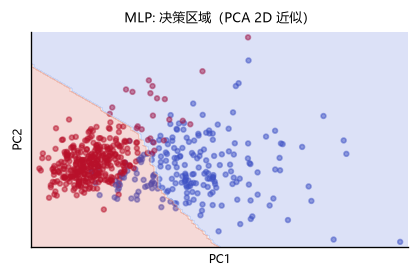

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(24, 12),
    max_iter=250,
    alpha=1e-4,
    random_state=42,
)
mlp.fit(X_train, y_train)
acc = accuracy_score(y_test, mlp.predict(X_test))
print("MLP test acc:", round(float(acc), 4))

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(StandardScaler().fit_transform(X))
xx = np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 100)
yy = np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 100)
grid_x, grid_y = np.meshgrid(xx, yy)
grid2d = np.c_[grid_x.ravel(), grid_y.ravel()]
# 逆变换回原空间近似可视化决策边界
grid_orig = pca.inverse_transform(grid2d)
z = mlp.predict(grid_orig)

fig, ax = plt.subplots(1, 1)
ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap="coolwarm", s=8, alpha=0.5)
ax.contourf(grid_x, grid_y, z.reshape(grid_x.shape), alpha=0.20, cmap="coolwarm")
ax.set_title("MLP: 决策区域（PCA 2D 近似）")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_xticks([])
ax.set_yticks([])
save_fig("01_mlp")
display(fig)
plt.close(fig)


## 2. 激活函数

**公式**：

$$
\mathrm{ReLU}(x)=\max(0,x),\quad
\sigma(x)=\frac{1}{1+e^{-x}},\quad
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

$\text{ReLU}(x)$=
\begin{cases}
x & x>0 \quad \text{导数}=1\\
0 & x\le0 \quad \text{导数}=0
\end{cases}当神经元处于激活状态\(x>0\)：导数 = 1。链式相乘的时候乘的是 1：
$1 \times1\times1\times... =1$
梯度不会被缩小，梯度可以完好地从最后一层，一路传回最前面的层。
靠前层的权重能拿到有效的梯度，可以正常更新，深层网络就可以训练起来。

⚠️ 注意前提：神经元要被激活\(x>0\)。
如果神经元一直\(x<0\)，导数 = 0，梯度直接断掉，这个神经元就 “死 ReLU”，再也不更新。

Tanh：导数最大值为1，比sigmoid大4倍，梯度衰减更慢，零中心输出，Z字震荡明显减轻，收敛更快。

softmax：逻辑回归解决的是非黑即白的二分类问题，如果面临多个类别需要升级为softmax回归，为每个类别计算一个独立得分，通过函数将所有得分转化为概率分布，所有类别概率总和严格为1。

**优缺点**：
- 阶跃函数：梯度无法传播，除x=0外导数恒为0，误差信号一碰到阶越函数就直接清零，信息损失太狠，大量数值信息在激活的瞬间被永久丢弃。
- Sigmoid：处处可导，天然概率解释输出（0，1）之间、平滑国度；但导数最大值出现在x=0，|x|一大就饱和，多层之后梯度只剩千分之几，深层几乎学不动，梯度消失；输出永远是正数，算出来的梯度往往长期保持同号；计算贵，天然饱和。
- Tanh：导数最大值为1，比sigmoid大4倍，梯度衰减更慢，零中心输出，Z字震荡明显减轻，收敛更快；本质仍然是S形，俩端饱和没有变，依赖指数函数，计算成本高。
- ReLU：当z<0，输出永远是0，当z>0,输出z自己。大幅缓减梯度消失，正半轴导数恒为1。计算快，只需一次比较，没有指数没有除法。天然稀释激活，负输出直接置0，任意一次前向只有部分神经元真正激活，自带正则化效果；可能出现死神经元，某次更新后预激活值恒为负，则输出永远0，导数永远0。输出无上界，深层+大参数下激活值可能一路放大，引发数值不稳定所有离不开BatchNorm。
- GELU：ReLU在x=0处硬性切断，换成一种柔和的软门-根据输入大小，以一定概率决定放出多少信号。但需要tanh、三次方、平方根比ReLU慢很多。

**使用**：
输出层：概率问题用Sigmoid或Softmax；普通隐藏层：很多场景下ReLU；Transformer或大模型：GELU或SiLU（Swish）。


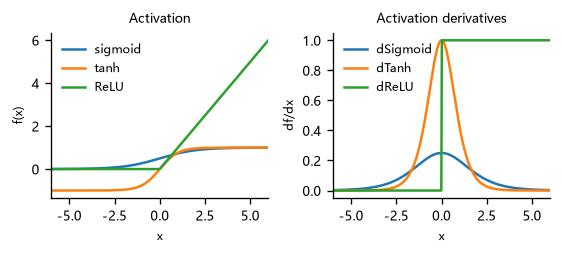

In [3]:
x = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

dsig = sigmoid * (1 - sigmoid)
dtanh = 1 - tanh**2
drelu = (x > 0).astype(float)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x, sigmoid, label="sigmoid")
ax[0].plot(x, tanh, label="tanh")
ax[0].plot(x, relu, label="ReLU")
ax[0].set_title("Activation")
ax[0].legend(frameon=False)
ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")

ax[1].plot(x, dsig, label="dSigmoid")
ax[1].plot(x, dtanh, label="dTanh")
ax[1].plot(x, drelu, label="dReLU")
ax[1].set_title("Activation derivatives")
ax[1].legend(frameon=False)
ax[1].set_xlabel("x")
ax[1].set_ylabel("df/dx")

for a in ax:
    a.set_xlim(-6, 6)

save_fig("02_activation", w=120, h=55)
display(fig)
plt.close(fig)


## 3. 反向传播（Backpropagation）

前向传播：沿着箭头方向计算每个节点的值。
反向传播：逆着箭头方向，用链式法则把局部梯度一路乘回输入端。复杂的多元复合求导被简化为“沿路径相乘局部梯度”，每个节点只关心自己的输入输出。
神经网络的本质：前向传播算误差、反向传播算梯度、梯度下降更新参数、再次前向传播。

**核心链式法则**：

$$
\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\frac{\partial a}{\partial z}\frac{\partial z}{\partial w}
$$

**要点**：
- 先前向算子再反向按图反推梯度
- 通过链式法则逐层累计梯度
- 是BP神经网络和Transformer训练的基础


Analytical dW1: [-0.1358 -0.2701 -0.2269 -0.155 ]
Analytical dW2: [0.1825 0.1884 0.7679 3.5157]


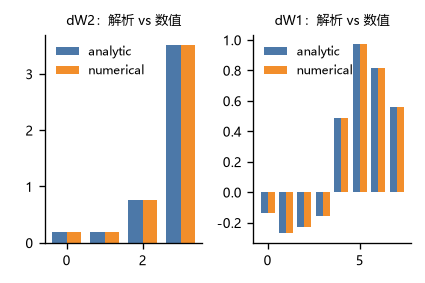

In [4]:
# 一个二维小网络，手算梯度并对比数值梯度
from sklearn.datasets import make_regression

X = RNG.uniform(-1, 1, (80, 2))
y = (X[:, 0] * 2 - X[:, 1] + 0.1 * RNG.randn(80))
y = y.reshape(-1, 1)

# 参数初始化
W1 = RNG.randn(2, 4) * 0.3
b1 = np.zeros((1, 4))
W2 = RNG.randn(4, 1) * 0.3
b2 = np.zeros((1, 1))


def relu(z):
    return np.maximum(0, z)


def relu_d(z):
    return (z > 0).astype(float)


def forward(x):
    h = relu(x @ W1 + b1)
    y_hat = h @ W2 + b2
    return y_hat, h


def loss(y_hat, y_true):
    return np.mean((y_hat - y_true) ** 2)

# 取一个样本做演示
x0 = X[:1]
y0 = y[:1]

y_hat, h = forward(x0)
res = y_hat - y0
L = loss(y_hat, y0)

g2 = 2 * res / 1

db2 = g2
# h is 1x4
dW2 = h.T @ g2

dh = g2 @ W2.T

dz1 = dh * relu_d(x0 @ W1 + b1)
dW1 = x0.T @ dz1

db1 = dz1

print("Analytical dW1:", np.round(dW1.flatten()[:4], 4))
print("Analytical dW2:", np.round(dW2.flatten(), 4))

# 数值梯度（中心差分）

def loss_single(params):
    W1n, W2n = params
    y_hat_n, _ = forward_single(x0, W1n, W2n, b1, b2)
    return float(loss(y_hat_n, y0))


def forward_single(x, W1q, W2q, b1q, b2q):
    hq = relu(x @ W1q + b1q)
    yq = hq @ W2q + b2q
    return yq, hq


def num_grad_W2(eps=1e-4):
    g = np.zeros_like(W2)
    for i in range(W2.size):
        E = np.zeros_like(W2)
        E.flat[i] = eps
        lp = forward_single(x0, W1, W2 + E, b1, b2)[0]
        lm = forward_single(x0, W1, W2 - E, b1, b2)[0]
        g.flat[i] = ((lp - y0) ** 2).mean() - ((lm - y0) ** 2).mean()
        g.flat[i] /= (2 * eps)
    return g


def num_grad_W1(eps=1e-4):
    g = np.zeros_like(W1)
    for i in range(W1.size):
        E = np.zeros_like(W1)
        E.flat[i] = eps
        lp = forward_single(x0, W1 + E, W2, b1, b2)[0]
        lm = forward_single(x0, W1 - E, W2, b1, b2)[0]
        g.flat[i] = ((lp - y0) ** 2).mean() - ((lm - y0) ** 2).mean()
        g.flat[i] /= (2 * eps)
    return g

numW1 = num_grad_W1()
numW2 = num_grad_W2()

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bar_width = 0.38
analytic_color = "#4C78A8"
numerical_color = "#F28E2B"

x_w2 = np.arange(4)
ax[0].bar(x_w2 - bar_width / 2, np.ravel(dW2), width=bar_width, color=analytic_color, label="analytic")
ax[0].bar(x_w2 + bar_width / 2, numW2.ravel(), width=bar_width, color=numerical_color, label="numerical")
ax[0].set_title("dW2：解析 vs 数值")
ax[0].legend(frameon=False)

x_w1 = np.arange(8)
ax[1].bar(x_w1 - bar_width / 2, np.ravel(dW1), width=bar_width, color=analytic_color, label="analytic")
ax[1].bar(x_w1 + bar_width / 2, numW1.ravel(), width=bar_width, color=numerical_color, label="numerical")
ax[1].set_title("dW1：解析 vs 数值")
ax[1].legend(frameon=False)

save_fig("03_backprop")
display(fig)
plt.close(fig)


## 4. 优化器

**演化路线**：
- **batch**：每次参数更新前先把整个训练集完整处理一遍。优势-每步沿全数据真实梯度，几乎无噪声。缺点-一次更新就要跑完全部数据，模型往往很久才能走几步。进入鞍点或梯度小的区域，没有噪声扰动来跳出去。
- **SGD**：随机抽一个样本，用它的梯度作为整体梯度的估计。优势-计算成本骤减、跳出局部最优。缺点-剧烈震荡、学习率衰减、对离群样本敏感。
- **mini-batch**：折中方案，每次随机抽一小批。比单样本SGD稳定，可并行前向反向，充分利用向量化，比Batch GD仍有噪声主力跳鞍。
- **Momentum**：不要只看当前这一步的梯度，把过去几步的运动趋势也考虑进来，方向一致的更新被持续强化，来回震荡的更新被逐步抵消。
- **AdaGrad**：给每一个参数单独维护一个历史梯度积累量，用它来自适应地调整这个参数地有效学习率。自适应学习率。缺陷是学习率单调衰减为0。
- **RMSProp**：不把训练以来所有的梯度平方都加起来，只保留近期地梯度信息。不在衰减到0，保留自适应。
- **Adam**：把动量与自适应学习率结合，引入惯性、自适应缩放、偏差矫正稳定初期。隐藏bug-权重衰减失效了，本该稳定的正则信号被自适应机制一同缩放，正则效果偏离原意。
- **AdamW**；新增项就是直接作用在参数上的权重衰减，不再走梯度通道，不会被自适应学习率机制污染。
- **Muon**：换了视角，神经网络里真正的主角是二维权重矩阵，正交化更新方向，把奇异值拉平后再走一步。


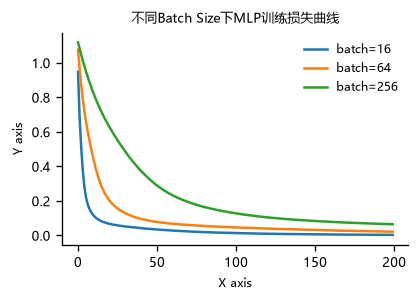

In [5]:
from sklearn.neural_network import MLPClassifier

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)

batch_sizes = [16, 64, 256]
loss_curves = {}
for bs in batch_sizes:
    model = MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="relu",
        batch_size=bs,
        max_iter=200,
        alpha=1e-4,
        random_state=42,
    )
    Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    model.fit(Xtr, ytr)
    loss_curves[bs] = np.array(model.loss_curve_)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for bs, c in loss_curves.items():
    ax.plot(c, label=f"batch={bs}")
ax.set_title("不同Batch Size下MLP训练损失曲线")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.legend(frameon=False)
save_fig("04_batch", h=65)
display(fig)
plt.close(fig)


## 5. 正则化

**L1/L2**：

$$
L=\sum_i \ell_i+\lambda\|w\|_2^2\quad(\text{L2}),\qquad
L=\sum_i \ell_i+\lambda\|w\|_1\quad(\text{L1})
$$

**要点**：
- L2（Ridge）：倾向于让所有权重均匀缩小向0靠拢，但不会精确为0，保持权重平滑分布。抑制大权重，降低复杂度
- L1（Lasso）：倾向于产生稀疏权重（许多参数直接变为0），相当于自动特征选择。会产生稀疏权重（特征选择效果）
- Dropout：随机关闭神经元，L1、L2从权重数值角度限制容量，Dropout则从网络结构多样性的角度做正则化，每次前向传播以一定概率随机将部分神经元的输出置为0，相当于在本次训练中将其关闭。神经元不能再依赖相邻特定神经元的输出，每个都必须学习独立有用的特征。
- Early Stopping：过拟合表现为验证指标在某个时刻开始恶化，那就再恶化前停止训练-监控验证集指标。连续若干个epoch没有改善就终止训练，并回退到表现最好的checkpoint。
- 数据增强：上述方法都通过限制模型容量来缓解过拟合，数据增强则扩大训练分布，对训练数据施加随机变换，让模型更难记住具体样本，被迫学习更通用的特征。


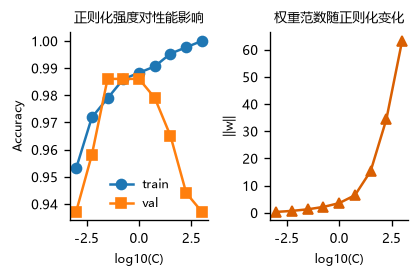

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Cs = np.logspace(-3, 3, 9)
train_acc = []
valid_acc = []
coef_norm = []
for C in Cs:
    lr = LogisticRegression(
        C=C,
        l1_ratio=0,
        solver="liblinear",
        random_state=42,
        max_iter=200,
    )
    lr.fit(Xtr, ytr)
    train_acc.append(accuracy_score(ytr, lr.predict(Xtr)))
    valid_acc.append(accuracy_score(yv, lr.predict(Xv)))
    coef_norm.append(np.linalg.norm(lr.coef_))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].plot(np.log10(Cs), train_acc, marker="o", label="train")
ax[0].plot(np.log10(Cs), valid_acc, marker="s", label="val")
ax[0].set_title("正则化强度对性能影响")
ax[0].set_xlabel("log10(C)")
ax[0].set_ylabel("Accuracy")
ax[0].legend(frameon=False)

ax[1].plot(np.log10(Cs), coef_norm, marker="^", color="#d95f02")
ax[1].set_title("权重范数随正则化变化")
ax[1].set_xlabel("log10(C)")
ax[1].set_ylabel(r"||w||")

save_fig("05_regularization")
display(fig)
plt.close(fig)


## 6. CNN（卷积神经网络）

CNN不是一层卷积直接看懂整张图，而是通过层层堆叠，把像素逐渐变成语义。前半段：Conv-ReLU-Pool：卷积提取局部模式，ReLU引入非线性，池化降低空间分辨率扩大有效视野。后半段：分类器，不在直接面对原始像素，而是处理卷积层提炼后的高层特征，最终输出类别得分。

卷积层：把局部模式变成特征图，在不展开图像、不做全连接的情况下，从图像中提取有意义的局部特征。使用一个小的权重矩阵，卷积核，在图像上滑动，每到一个位置，就把当前窗口中的像素与卷积核权重逐项相乘、再相加。

特征图：当一个卷积核滑完整张图后，每个位置都会得到一个响应值，把这些响应值按空间位置排列起来，就得到这个卷积核对应的特征图。

padding：给图像边缘补零，为了保证卷积后的图像尺寸不变，可以再图像边缘补零，填充以后，卷积核也可以覆盖到边界附近的位置。

输出通道数=卷积核数量，一张特征图只能表示一种检测结果，如果希望同一层同时检测16种局部模式，就需要16个卷积核。

ReLU：让特征具备非线性，后续层才有能力把不同位置、不同通道上的响应组合成更复杂的视觉特征。

池化层：降低分辨率，使用一个小窗口在特征图上滑动，对空间维度做下采样，最常见的是最大池化。（一个2×2的最大池化窗口，会在每个局部区域中保留响应最强的那个值，使特征图的高和宽减半。）池化把相邻区域压缩之后，下一层卷积核在特征图上的尺寸可以保持不变，但对应回原图时覆盖的区域更大。让网络在看完局部之后，逐渐有能力看向整体。

卷积部分输出的是C×H×W结构：有通道，有高度，也有宽度，但分类任务最终需要的是对每个类别对应的判断结果。Flatten：特征图拉成一维向量。Linear：映射到类别数维度。Softmax：推理时转成概率分布。


**卷积**（二维）

$$
(S * K)(i,j)=\sum_m\sum_n S(i-m,j-n)K(m,n)
$$

**优缺点**：
- 优点：局部平移不变性、参数共享
- 缺点：对长距离关系建模弱，需要堆叠更多层


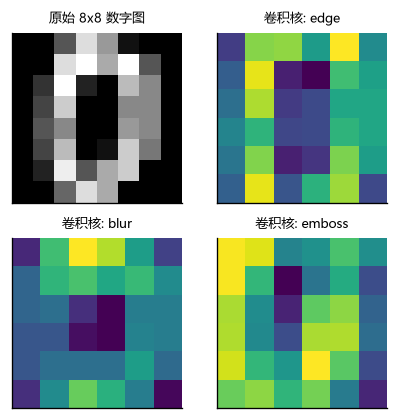

In [7]:
from sklearn.datasets import load_digits

def conv2d_manual(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    out = np.zeros((H - kH + 1, W - kW + 1))
    for i in range(H - kH + 1):
        for j in range(W - kW + 1):
            patch = img[i:i+kH, j:j+kW]
            out[i, j] = np.sum(patch * kernel)
    return out


digits = load_digits()
img = digits.images[0]
kernels = {
    "edge": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    "blur": np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9.0,
    "emboss": np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
}

fm = [conv2d_manual(img, k) for k in kernels.values()]

fig, ax = plt.subplots(2, 2, figsize=(6.6, 6.6))
ax = ax.ravel()
ax[0].imshow(img, cmap="gray")
ax[0].set_title("原始 8x8 数字图")
for i, (name, feature) in enumerate(zip(kernels.keys(), fm), start=1):
    ax[i].imshow(feature, cmap="viridis")
    ax[i].set_title(f"卷积核: {name}")
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

save_fig("06_cnn", w=90, h=90)
display(fig)
plt.close(fig)


## 7. RNN（循环神经网络）

处理序列数据，比如句子文字、语音、时间序列。普通神经网络每一条输入之间互相独立，RNN 可以记住前面输入的信息。序列很长的时候，早期的记忆信息会慢慢消失，出现梯度消失 / 梯度爆炸。

RNN每一步都会产生隐藏状态，但输出几次、在那里输出，取决于具体任务，常见的有三种：
1、整体分类：读完整个序列，只在最后输出一次；损失来自整体标签。
2、序列标注：每个token都输出标签，补齐位置通过mask排除。
3、序列生成：每个位置预测下一个token，汇总所有有效位置的损失。

**递推**：

$$
\mathbf h_t = \phi\left(W_x\mathbf x_t + W_h\mathbf h_{t-1}+\mathbf b\right)
$$

RNN擅长建模“前后依赖”，但长序列容易梯度消失/爆炸。

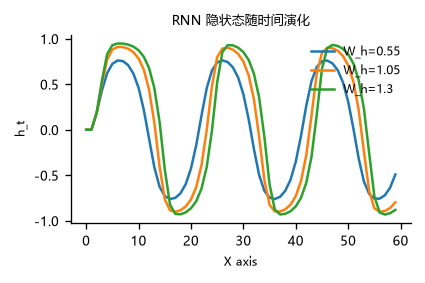

In [8]:
# 使用一段时间序列演示不同Recurrent权重下状态衰减
T = 60
x = np.sin(np.linspace(0, 6 * np.pi, T))
W_h_vals = [0.55, 1.05, 1.30]
fig, ax = plt.subplots()
for w_h in W_h_vals:
    h = [0.0]
    for t in range(T - 1):
        nxt = np.tanh(0.6 * x[t] + w_h * h[-1])
        h.append(float(nxt))
    ax.plot(h, label=f"W_h={w_h}")

ax.set_title("RNN 隐状态随时间演化")
ax.set_xlabel("X axis")
ax.set_ylabel("h_t")
ax.legend(frameon=False, loc="upper right")
save_fig("07_rnn")
display(fig)
plt.close(fig)


## 8. LSTM（长短期记忆）/GRU（门控循坏单元）

**LSTM**

$$
f_t=\sigma(W_f[x_t,h_{t-1}]+b_f),\quad
i_t=\sigma(W_i[x_t,h_{t-1}]+b_i),\quad
\tilde c_t=\tanh(W_c[x_t,h_{t-1}]+b_c)
$$

$$
 c_t=f_t\odot c_{t-1}+i_t\odot \tilde c_t,\quad
 h_t=o_t\odot\tanh(c_t)
$$

LSTM把长期记忆从隐藏态中分离出来，细胞状态ct长期记忆路径，复杂把需要保留的信息传向后续时间步。

遗忘门：旧记忆继续保留多少，f_t为1，旧信息保留；f_t为0，旧信息清除。

输入门：新内容可以写入什么、实际写入多少。i_t回答候选内容实际写入多少。

细胞状态用加法完成更新c_t，保留下来的旧记忆与筛选后的新记忆相加，形成当前细胞状态。

输出门：当前需要暴露哪些记忆，tanh先把细胞状态压缩到（-1，1），输出门再逐维筛选，生成当前隐藏状态。信息可以继续保存在c_t中，暂时不出现在h_t中，直到后续上下文需要它。


**GRU**
不再单独维护细胞状态，跨时间传递的信息与当前对外表示统一放在h_t中。

重置门：生成候选状态时参考多少过去。

更新门：旧状态与候选各采用多少。


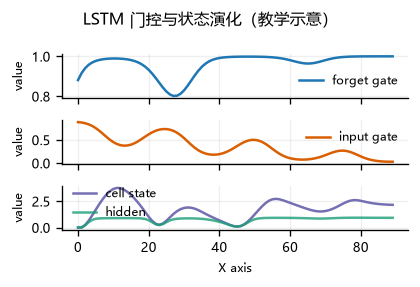

In [9]:
T = 90
x = np.sin(np.linspace(0, 8 * np.pi, T))
# 简化的门控曲线示例（固定参数）
forget_gate = 1 / (1 + np.exp(-(2 + 0.05 * np.arange(T) + 2 * np.sin(np.arange(T) / 6))))
input_gate = 1 / (1 + np.exp(-(1 - 0.04 * np.arange(T) + np.cos(np.arange(T) / 4))))
state = [0.0]
cell = [0.0]
for t in range(T - 1):
    c = forget_gate[t] * cell[-1] + input_gate[t] * np.tanh(x[t])
    h = (1 / (1 + np.exp(-(2 + 0.01 * t)))) * np.tanh(c)
    cell.append(float(c))
    state.append(float(h))

fig, ax = plt.subplots(3, 1, figsize=(7, 5.8), sharex=True)
ax[0].plot(forget_gate, label="forget gate")
ax[1].plot(input_gate, label="input gate", color="#d95f02")
ax[2].plot(cell, label="cell state", color="#7570b3")
ax[2].plot(state, label="hidden", color="#1b9e77", alpha=0.8)
for a in ax:
    a.set_ylabel("value")
    a.grid(alpha=0.2)
    a.legend(frameon=False)
ax[2].set_xlabel("X axis")
fig.suptitle("LSTM 门控与状态演化（教学示意）")
save_fig("08_lstm")
display(fig)
plt.close(fig)


## 9. RNN Encoder-Decoder（统计机器翻译）/seq2seq（序列到序列）

**RNN Encoder-Decoder**

前一个GRU负责编码，将其压缩成一个固定维度向量，后一个GRU负责解码，根据这个向量逐步生成目标语言短语。

**seq2seq**：
- 编码器：将输入序列映射到上下文向量
- 解码器：基于上下文逐步生成目标序列
模型训练不能用自身预测，若模型始终使用模型自己的预测，第一个位置产生的错误会改变第二个位置的输入，后面误差很快叠加，模型很难学到稳定的目标序列规律。
- 监督学习训练时知道正确结果，Teacher Forcing：把目标序列错开一位，把真实的前一个作为当前输入，实际只需把序列整体右移一位作为解码器输入，原始目标序列作为监督标签，不会改变损失函数，改变的是解码器每个时间步的输入内容。

- 优点：可处理变长输入输出
- 缺点：标准结构信息瓶颈明显（长序列表现下降）


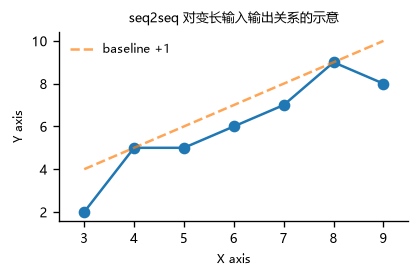

In [10]:
# 可视化：短序列变长映射长度关系
rng = np.random.default_rng(42)
src_len = np.array([3, 4, 5, 6, 7, 8, 9])
tgt_len = src_len + rng.integers(-1, 2, size=len(src_len))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(src_len, tgt_len, marker="o")
ax.plot(src_len, src_len + 1, linestyle="--", alpha=0.7, label="baseline +1")
ax.set_xticks(src_len)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_title("seq2seq 对变长输入输出关系的示意")
ax.set_xlim(2.5, 9.5)
ax.legend(frameon=False)
save_fig("09_seq2seq")
display(fig)
plt.close(fig)


## 10. 注意力机制（Attention）

Decoder不再依赖一个固定不变的上下文向量，而是在不同解码时间步从Encoder的全部输出中选择当前最相关的信息。

一次完整的Attention计算：得到当前状态→与每一个Encoder状态算匹配分数→Softmax转为权重→加权求和→结合解码状态与上下文预测输出

输入序列全程未变，但Decoder状态随输出进度更新，每个解码时间步都得到不同的注意力权重和上下文向量。

纯seq2seq和引入Attention区别在于解码器：编码器本来就会算出全部隐藏状态，无Attention版只取走最后一个作为解码器初始状态；有Attention版把完整的隐藏状态序列交给解码器。


**缩放点积注意力**：

$$
\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

**关系**：
- 重点建模“当前要看的上下文”
- 是Transformer的核心模块


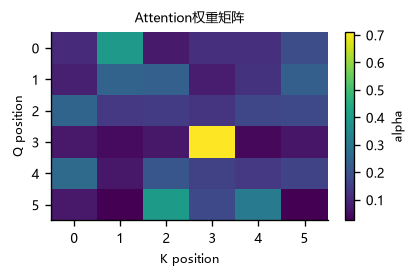

In [11]:
import numpy as np
q_len = 6
k_len = 6
rng = np.random.RandomState(42)
Q = rng.normal(0, 1, (q_len, 4))
K = rng.normal(0, 1, (k_len, 4))
V = rng.normal(0, 1, (k_len, 1))

scores = Q @ K.T / np.sqrt(4)
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
att = weights @ V

fig, ax = plt.subplots(figsize=(6.6, 3.4))
im = ax.imshow(weights, cmap="viridis", aspect="auto")
ax.set_title("Attention权重矩阵")
ax.set_xlabel("K position")
ax.set_ylabel("Q position")
fig.colorbar(im, ax=ax, label="alpha")
save_fig("10_attention")
display(fig)
plt.close(fig)


## 11. Transformer

核心：自注意力 Self‑Attention + 残差连接 + LayerNorm + 前馈网络 FFN；分为 Encoder（编码器）、Decoder（解码器）两大块。靠注意力机制，能同时看完整段文字，既可以读懂文本，也能自动生成文本，现在所有大语言模型的底层骨架。

Transformer 与 Seq2Seq 一样，仍然采用 Encoder–Decoder 架构

① 转换输入 · Embedding  源序列的 Token 经过 Input Embedding，转换成向量表示。

② 理解源序列 · Encoder  为每个输入 Token 生成包含上下文信息的表示。

③ 生成目标表示 · Decoder  读取 Encoder 输出，结合已生成的目标前缀，产生当前位置的隐藏表示。

④ 映射到词表 · Linear  把隐藏表示映射到词表空间，为每个候选 Token 打分。

⑤ 转换为概率 · Softmax  把分数转换成总和为 1 的概率分布。

⑥ 预测下一个 Token · 自回归  选出的 Token 加入目标前缀，经 Output Embedding 再次输入 Decoder，重复直到生成 <EOS>。

整体流程与 Seq2Seq 没有本质区别，真正发生变化的是 Encoder 和 Decoder 内部生成上下文表示的方式--Self-Attention让每个位置直接与整个序列建立连接，同一层中的多个位置可以组织成矩阵同时计算。



**结构特点**：
- 堆叠自注意力（Self-Attention）
- 前馈网络
- 残差连接 + LayerNorm

对序列长度的建模更高效，支持并行计算。

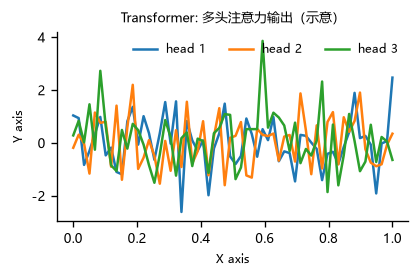

In [12]:
# 关系式子：多头注意力输入后再经过ffn，输出残差相加
x = np.linspace(0, 1, 60)
heads = [rng.normal(size=60), rng.normal(size=60), rng.normal(size=60)]
weights = np.vstack(heads)

fig, ax = plt.subplots(figsize=(7, 3.8))
for i in range(weights.shape[0]):
    ax.plot(x, weights[i], label=f"head {i+1}")
ax.set_title("Transformer: 多头注意力输出（示意）")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.legend(frameon=False, ncol=3)
save_fig("11_transformer")
display(fig)
plt.close(fig)


## 12. 过拟合与欠拟合

**概念**：
- 欠拟合：训练/验证误差都高，未能充分学习训练数据中的规律，导致其在训练集和测试集上的表现都很差。
- 过拟合：训练误差低、验证误差高，不仅学到了数据中的真实规律，还将噪声也一并记住了，导致其在训练集上表现优异，但在测试集上表现明显下降。
- 诊断工具：学习曲线，假设数据的真实规律是y=x的平方，degree=1：线性模型，无法捕捉二次关系，导致欠拟合；degree=2：二次多项式，与真实数据生成过程匹配，良好拟合；degree=15：高次多项式，过度拟合训练数据中的噪声，导致过拟合。学习曲线分析：欠拟合-训练和验证误差都高，且差距不大，加数据也没有用。良好拟合-训练和验证误差都低，逐渐收敛。过拟合-训练误差极低，验证误差极高，差距大，加数据可能有帮助。解决欠拟合：1、特征工程：添加高次项；特征交叉：组合多个特征。数学变换：对数、指数等。领域特征：结合业务知识。2、增加训练轮数。3、增加模型复杂度。解决过拟合：增加训练数据（戈多数据让噪声被稀释）、正则化（给模型复杂度加惩罚，限制权重大小，防止死记硬背）、降低模型复杂度、特征选择（主动去掉无关或冗余的特征，减少干扰信号）、早停（在验证集误差开始上升时，及时停止训练过程）、数据增强。
- 正则化：在损失函数中额外增加一个惩罚项，系数越大罚的越重，让模型尽可能用小的系数拟合。L2正则化（岭回归）：惩罚所有权重的平方和-将权重均匀压缩到接近0的小值，但不会恰好等于0，变相稳定。L1正则化（Lasso）：惩罚所有权重的绝对值之和-将不重要特征的权重直接压缩到0，相当于自动进行特征选择。



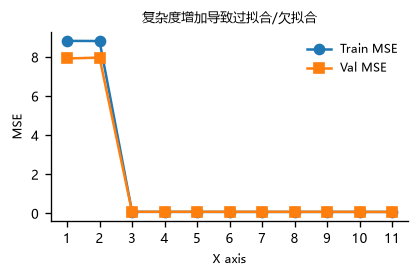

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(42)
X = np.linspace(-3, 3, 180).reshape(-1, 1)
y = 0.7 * X[:, 0] ** 3 - 0.4 * X[:, 0] + 0.3 * rng.randn(X.shape[0])

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.3, random_state=42)
degs = np.arange(1, 12)
tr_mse, va_mse = [], []
for d in degs:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(Xtr, ytr)
    tr_mse.append(mean_squared_error(ytr, model.predict(Xtr)))
    va_mse.append(mean_squared_error(yv, model.predict(Xv)))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(degs, tr_mse, marker="o", label="Train MSE")
ax.plot(degs, va_mse, marker="s", label="Val MSE")
ax.set_xticks(degs)
ax.set_xlabel("X axis")
ax.set_ylabel("MSE")
ax.set_title("复杂度增加导致过拟合/欠拟合")
ax.legend(frameon=False)
save_fig("12_overfit")
display(fig)
plt.close(fig)


## 13. 数据预处理

常见步骤：
1. 缺失值处理
2. 编码分类变量
3. 标准化/归一化

-数据集划分：先划分数据集，再做预处理。训练集:训练模型，学习数据中的规律。验证集：调整超参数，评估模型在未见过数据上的表现。测试集：模拟真实数据，最终评估模型泛化能力。
-数据探索分析（EDA）：给数据做一次全面体检，直观地发现数据中的问题和规律。使用.info()查看数据集的数据类型和缺失情况。
-数据清洗-处理重复值：对于数据中重复的行直接删除即可。
-数据清洗-处理缺失值：按缺失比例决定（缺失极低<5%，且为随机缺失，直接删除对应样本行；缺失极高>70%,该特征信息量匮乏，通常直接删除整列）、按特征类型选择:数值型特征（用均值或中位数填充，中位数对极端值不敏感，在数据偏态时更加稳健）；类别型特征（用众数填充，或增加“Unknown”类别保留业务信息）。
-数据清洗-异常值检测：指显著偏离其他观测值的极端值，可以用箱线图检测。比如使用统计学方法识别并处理票价中的极端异常值，采用截断策略，将过高的票价强行拉回到合理范围。

**特征编码**：将文本映射为数值，使模型能进行数学运算
-序数编码(Ordinal Encoding)：将类别映射为整数，严格保留顺序关系，适合特征本身具有明确等级。
-独热编码(One-Hot Encoding)：把每个类别变成独立列，用0和1表示，消除虚假的大小关系，适合无序分类特征。
-标签编码(Label Encoding):简单映射为整数，不保证顺序，但引入了数值大小，适合二分类特征如性别、分类任务的目标变量、树模型。

**特征缩放**：在数据集中，部分特征的量纲差异很大，如果不进行缩放，模型会错误的认为数值较大的特征更重要，赋予其过大的权重。
-标准化：将数据转化为均值为0、标准差为1的分布。特点：不会强制压缩到特定区间，基于均值和标准差的计算，易受到异常值影响，得益于异常值清洗，整体相对稳定。
-归一性：将数据线性变换到一个固定的区间，通常是[0,1],严格限定数据范围，确保结果不会出现负数，受异常值影响极其明显。

**作用**：减少数据偏差、提升数值稳定性。

Transformed shape: (150, 7)


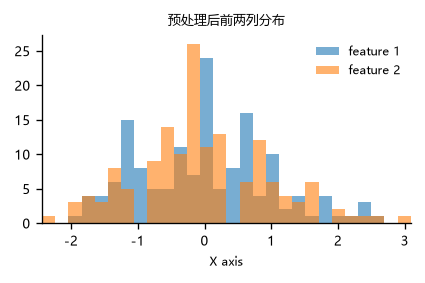

In [14]:
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
df = iris.frame.copy()
# 构造一个“类别列”与缺失值用于演示
rng = np.random.RandomState(42)
df.loc[rng.choice(len(df), 15, replace=False), "sepal length (cm)"] = np.nan
binned = pd.qcut(df["petal length (cm)"], q=3, labels=["short", "mid", "long"])
df["petal_bin"] = binned

num_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
cat_cols = ["petal_bin"]

cat_transform = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]
)
num_transform = Pipeline(
    [
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", StandardScaler()),
    ]
)

pre = ColumnTransformer(
    [("num", num_transform, num_cols), ("cat", cat_transform, cat_cols)],
    remainder="drop",
)

Xt = pre.fit_transform(df[num_cols + cat_cols])
print("Transformed shape:", Xt.shape)

# 简要可视化前两维分布
Xn = pd.DataFrame(Xt.toarray() if hasattr(Xt, "toarray") else Xt).iloc[:, :2].values
bin_edges = np.histogram_bin_edges(Xn.ravel(), bins=28)
fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.0))
ax.hist(Xn[:, 0], bins=bin_edges, alpha=0.6, label="feature 1")
ax.hist(Xn[:, 1], bins=bin_edges, alpha=0.6, label="feature 2")
ax.set_title("预处理后前两列分布")
ax.set_xlabel("X axis")
ax.set_xlim(bin_edges[0], bin_edges[-1])
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
save_fig("13_preprocessing")
display(fig)
plt.close(fig)


## 14. 模型评估
线性回归：

1. MAE（平均绝对误差）

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

• 核心思想：计算预测值与真实值偏差的绝对值，再求平均。

• 优点：直观易懂，单位与目标变量完全一致；对异常值相对不敏感，不会过度放大极端错误。

• 缺点：在数学上绝对值在零点不可导，作为损失函数优化时不如平方项方便。

2. MSE（均方误差）
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

• 核心思想：计算预测值与真实值偏差的平方，再求平均。

• 特点：平方操作会放大大误差的影响。如果业务场景对大偏差零容忍（医疗、自动驾驶），MSE 是很好的指标。

• 缺点：单位被平方了（例如“平方万美元”），失去了直观的业务含义。

3. RMSE（均方根误差）
$$\text{RMSE} = \sqrt{\text{MSE}}$$

• 核心思想：对 MSE 开根号。

• 为什么最常用？

1. 单位还原：量纲回到了和目标变量一致，业务上容易解释。

2. 惩罚大误差：继承了 MSE 对大偏差敏感的特性。

• 在实际工程和数据科学竞赛（如 Kaggle）中，RMSE 是回归任务的默认标准。

4. R^2（决定系数）
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
无量纲指标：衡量模型消除了总方差中多大比例的不确定性，可在不同数据集间横向比较。

• R^2 = 1：完美预测，没有任何误差。

• R^2 = 0：模型表现和直接预测所有样本的平均值一样，等于没学到有效特征。

• R^2 < 0：模型预测得比直接猜平均值还差（通常是因为选错了模型或存在严重Bug）。
核心指标：Accuracy、Precision、Recall、F1、ROC-AUC 等。


5.残差分析：告诉我们模型在哪里表现好、哪里差。

$$e_i = y_i - \hat{y}_i \quad (\text{真实值} - \text{预测值})$$


6.交叉验证：剔除随机性带来的偏差-单次评估结果可能依赖于天气，为了获取更稳定、更具统计显著性的评估结果，采用K-Fold交叉验证，将数据分为K份，每一轮取1份作为测试集，剩余K-1份作为训练集，重复K轮，最终报告K次评估结果的均值和标准差。

逻辑回归：
TP：真正例；FN：假负例；FP：假正例；TN：真负例。
1. 精确率 Precision（P）:预测为正类的样本中，真正是正类的比例。

$$P=\frac{TP}{TP+FP}$$
2. 召回率 Recall（R）:所有真正的正类中，被成功预测出来的比例。

$$R=\frac{TP}{TP+FN}$$
3. F1分数：精确率和召回率的调和平均，俩者都高，F1才高。

$$F1=2\times\frac{P\times R}{P+R}$$

acc 0.986 auc 0.9977


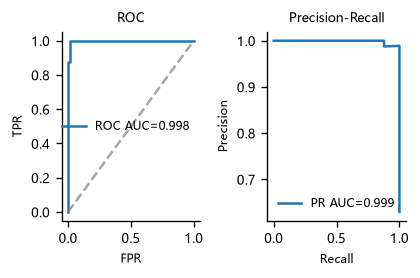

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_recall_curve, average_precision_score)

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
logit = LogisticRegression(max_iter=500, random_state=42)
logit.fit(Xtr, ytr)
p = logit.predict_proba(Xv)[:, 1]
y_pred = logit.predict(Xv)

fpr, tpr, _ = roc_curve(yv, p)
roc_auc = auc(fpr, tpr)
pr, re, _ = precision_recall_curve(yv, p)
pr_auc = average_precision_score(yv, p)

print("acc", round(accuracy_score(yv, y_pred), 4), "auc", round(roc_auc, 4))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
ax[0].set_title("ROC")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].legend(frameon=False)

ax[1].plot(re, pr, label=f"PR AUC={pr_auc:.3f}")
ax[1].set_title("Precision-Recall")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend(frameon=False)
save_fig("14_evaluation")
display(fig)
plt.close(fig)


## 15. 损失函数

常见：
- 线性回归：均方误差(MSE): $L=\frac{1}{N}\sum (y-\hat y)^2$
- 平均绝对误差(MAE): $L=\frac{1}{N}\sum|y-\hat y|$

- 逻辑回归：交叉熵损失 (Cross-Entropy Loss)


$$J(\theta) = -\frac{1}{m}\sum_{i=1}^m \Big[y_i \log(\hat{y}) + (1-y_i)\log(1-\hat{y})\Big]$$

公式看着长，但逻辑很简单：因为真实标签 y 要么是 0 要么是 1，所以永远只有一项在起作用。
真实标签 损失项 含义

- 预测概率越接近 1，损失越小；接近 0 时损失
- 预测概率越接近 0，损失越小；接近 1 时损失

交叉熵是一个严格的凸函数，无论初始权重在哪里，都能引导模型快速且稳定地收敛到全局最优点。

**关系**：
- 回归常用MSE/MAE，分类常用交叉熵（概率输出）。


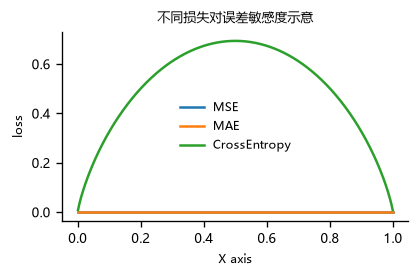

In [16]:
y_true = np.linspace(0.001, 0.999, 400)
y_pred = np.linspace(0.001, 0.999, 400)

mse = (y_true - y_pred) ** 2
mae = np.abs(y_true - y_pred)
ce = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(y_true, mse, label="MSE")
ax.plot(y_true, mae, label="MAE")
ax.plot(y_true, ce, label="CrossEntropy")
ax.set_title("不同损失对误差敏感度示意")
ax.set_xlabel("X axis")
ax.set_ylabel("loss")
ax.legend(frameon=False)
save_fig("15_loss")
display(fig)
plt.close(fig)


## 16. 决策树

**概念**：一种模仿人类决策时层层提问方式的机器学习算法。将数据按照不同特征进行递归分裂，最终形成倒立的树状结构。
决策树在选择最佳分裂特征时，需要一个数学指标来量化节点的混乱程度或纯度。
衡量纯度指标：
1、熵：用来衡量一个节点中各类别分布的混乱程度。50%，熵值最高，最混乱。100%与0%，熵值为0，最纯。
2、信息增益：用某个特征分裂之后，混乱程度下降了多少。信息增益=分裂前的熵-分裂后的熵。信息增益越大，说明特征区分能力越强。容易过拟合。
3、基尼系数（基尼不纯度 Gini Impurity）：用于决策树CART算法，衡量一个节点里数据“杂不杂（纯度）”
$$Gini(D)=1-\sum_{k=1}^K p_k^2$$
$p_k$ = 当前节点中第 k 类样本所占比例
直观理解：随机从节点抽2个样本，两个样本不是同一类的概率。
基尼系数 越小 → 节点越纯净
极端：节点全部是同一类，Gini=0（最纯净）
基尼系数 越大 → 数据越混乱、类别混杂
和信息熵简单对比
• 信息熵：里面带有 \log 对数运算，计算慢
• 基尼系数：只有加减、平方，没有对数，运算更快
剪枝：如果任由决策树肆意生长，会为了把每一个异常值都分对，长出无数繁琐的分支，导致过拟合，需要剪掉多余细节，保留核心主干。
1、预剪枝：在树往下生长的过程中，提前设定规则，触及规则强制停止。eg限制最大深度、限制叶节点最少样本数。 实现简单、计算量小。
2、后剪枝：先让树毫无保留地生长到最大，然后再从下往上检查，剪掉不影响准确率的分支。大数据下计算成本高。

**优缺点**：
- 优点：可解释性强，训练快
- 缺点：高方差，容易过拟合


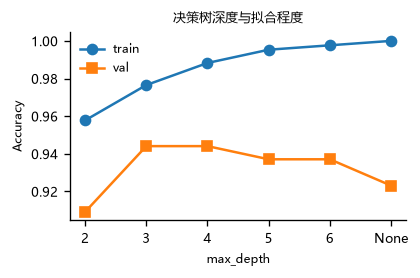

In [17]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

depths = [2, 3, 4, 5, 6, None]
tr, va = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(Xtr, ytr)
    tr.append(accuracy_score(ytr, dt.predict(Xtr)))
    va.append(accuracy_score(yv, dt.predict(Xv)))

fig, ax = plt.subplots()
labels = ["2", "3", "4", "5", "6", "None"]
ax.plot(labels, tr, marker="o", label="train")
ax.plot(labels, va, marker="s", label="val")
ax.set_title("决策树深度与拟合程度")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
save_fig("16_decision_tree")
display(fig)
plt.close(fig)


## 17. 随机森林

**核心机制**：
- 不再依赖一颗树做决定，而是通过随机采样建立成百上千棵各不相同的决策树。预测时让所有树独立做判断，最终汇总结果。
- 有效中和了单颗树的偏见和错误，让模型准确又稳健。

双重随机性：为了保证每棵树的多样性，算法引入了双重随机性。
- 样本随机：Bootstrap（有放回抽样）：假设训练集有N个样本，每次训练一棵树时，从原数据集中随机有放回地抽取N个样本，构成该树专属训练子集。
- 特征随机：Random Subspace（特征子空间）：在决策树的每个节点进行分裂时，并不考虑全部特征，而是随机抽取其中一个子集，仅在这些候选特征中寻找最优分裂点。
免费的验证集：Bootstrap采样时，每棵树大约有三分之一样本没有参与训练，这些被称为带外样本（OOB），天然的验证集，省去了额外划分验证集和交叉验证的开销。
特征重要性：帮助理解哪些因素在起作用，哪些可以舍弃。基于不纯度减少-统计特征在所有节点带来的不纯度下降两之和。基于排列的重要性-将特征值随机打乱，观察模型性能下降程度。下降越多越重要。

**优缺点**：
- 优点：泛化稳定、抗过拟合
- 缺点：模型较大、可解释性较弱


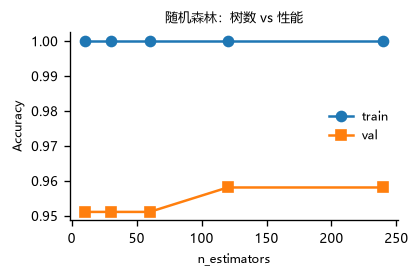

In [18]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

trees = [10, 30, 60, 120, 240]
tr, va = [], []
for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(Xtr, ytr)
    tr.append(accuracy_score(ytr, rf.predict(Xtr)))
    va.append(accuracy_score(yv, rf.predict(Xv)))

fig, ax = plt.subplots()
ax.plot(trees, tr, marker="o", label="train")
ax.plot(trees, va, marker="s", label="val")
ax.set_title("随机森林：树数 vs 性能")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
save_fig("17_random_forest")
display(fig)
plt.close(fig)


## 18. 集成学习

常见的有Bagging和Boosting：
Bagging（少数服从多数）算法代表随机森林；
Boosting（接力纠错）树依次训练，一颗接一颗，每棵新树专注于前面树犯的错，最终所有树的预测累加起来，代表算法XGBoost、LightGBM、CatBoost。
- GBDT（梯度提升决策树）：计算每个样本上的负梯度，即当前模型最应该修正的方向。训练一颗决策树去拟合这些负梯度，把这棵树乘学习率加到现有的模型上，相当于沿着下坡方向走一小步。

常见：Bagging、Boosting、Stacking。


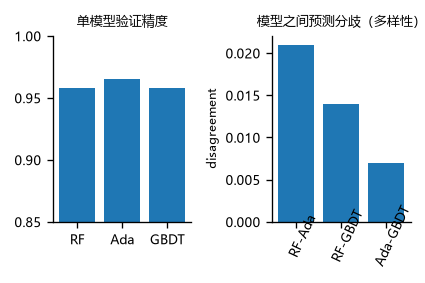

In [1]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

models = {
    "RF": RandomForestClassifier(n_estimators=150, random_state=42),
    "Ada": AdaBoostClassifier(n_estimators=120, random_state=42),
    "GBDT": GradientBoostingClassifier(n_estimators=150, random_state=42),
}

accs = {}
preds = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    pred = m.predict(Xv)
    preds[name] = pred
    accs[name] = accuracy_score(yv, pred)

# 简单多样性：两两预测不一致比例
names = list(models.keys())
import itertools
div = []
label_pairs = []
for a, b in itertools.combinations(names, 2):
    disagree = np.mean(preds[a] != preds[b])
    div.append(disagree)
    label_pairs.append(f"{a}-{b}")

fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
ax[0].bar(accs.keys(), accs.values())
ax[0].set_title("单模型验证精度")
ax[0].set_ylim(0.85, 1)

ax[1].bar(label_pairs, div)
ax[1].set_title("模型之间预测分歧（多样性）")
ax[1].set_ylabel("disagreement")
plt.setp(ax[1].get_xticklabels(), rotation=65, ha="center", rotation_mode="anchor")
save_fig("18_ensemble")
display(fig)
plt.close(fig)


## 19. XGBoost

对梯度提升决策树做了优化。XGBoost是基于梯度提升树的高效实现。

**核心改进**

• 正则化：在目标函数中显式加入树复杂度的惩罚项（叶节点数量 + 叶节点权重的 L2 正则），有效防止过拟合。

• 二阶梯度信息：经典 GBDT 只用一阶梯度，XGBoost 同时利用二阶梯度，使得分裂点选择更精准。

• 工程优化：支持列采样、缓存感知访问、核外计算等，使得单机处理上亿样本成为可能。

• 内置正则化和 Early Stopping：训练过程更可控。

## LightGBM
大数据集训练速度是XGBoost的5-10倍

**核心改进**
• 直方图算法：XGBoost 默认会去遍历所有数据点寻找分裂点；而 LightGBM 将连续的浮点特征分段（分桶）成离散的直方图。寻找分裂点时只需要遍历这些分桶，计算量呈指数级下降，且内存占用极小。

• 带深度限制的 Leaf-wise 生长策略：传统决策树是一层一层整齐生长的（Level-wise）。LightGBM 则是谁的残差大就顺着谁往下长（Leaf-wise），这导致树的结构不对称，但在同等叶子节点下能达到更高的精度。

• 引入了单边梯度采样（GOSS）和互斥特征捆绑（EFB）两大黑科技，进一步将速度推向极限。

## CatBoost
针对类别特征的处理推出的，处理具有大量类别型特征的业务。

**核心改进**

• 原生支持类别特征：以前用XGBoost，开发者必须手动把类别特征转换成One-hot编码。CatBoost可以直接把类别特征扔进去，它内部有一套很强大的（Target Statistics）自动处理。

• 排序提升：GBDT类算法有一个隐藏预测偏移，即当前训练数据的目标值影响了当前模型的构建。CatBoost通过一种极其严谨的排序策略，确保在训练每一个样本时，只使用排在它前面的样本信息，极大地提升了泛化能力。

• 对称树结构：它强制生成的决策树是完全对称的，这使得预测时的速度（推理速度）比XGBoost和LightGBM都要快得多。

三者选择：
追求极致精度：XGBoost或LightGBM
大数据集，需要快速训练：LightGBM
数据中有大量类别特征：CatBoost

C:\Users\fwj\PycharmProjects\sxjm\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:30:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


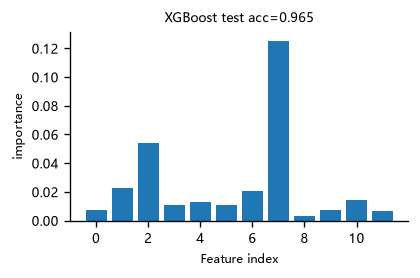

In [20]:
try:
    import xgboost as xgb
except Exception:
    xgb = None

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

if xgb is not None:
    model = xgb.XGBClassifier(
        n_estimators=180,
        learning_rate=0.08,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
    )
    model.fit(Xtr, ytr)
    acc = accuracy_score(yv, model.predict(Xv))
    imp = model.feature_importances_
    title = f"XGBoost test acc={acc:.3f}"
else:
    # 回退：用GBDT替代（仅用于离线演示）
    model = GradientBoostingClassifier(n_estimators=180, random_state=42)
    model.fit(Xtr, ytr)
    acc = accuracy_score(yv, model.predict(Xv))
    imp = np.abs(model.feature_importances_)
    title = f"Fallback(GBDT) test acc={acc:.3f}"

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(np.arange(len(imp))[:12], imp[:12])
ax.set_title(title)
ax.set_xlabel("Feature index")
ax.set_ylabel("importance")
save_fig("19_xgboost")
display(fig)
plt.close(fig)


## 20. GBDT（梯度提升树）

计算每个样本上的负梯度，即当前模型最应该修正的方向。训练一颗决策树去拟合这些负梯度，把这棵树乘学习率加到现有的模型上，相当于沿着下坡方向走一小步。GBDT逐步拟合负梯度（残差）作为“新树”，逐步减少损失。

**优点**：
- 处理非线性关系能力强
- 无需复杂归一化


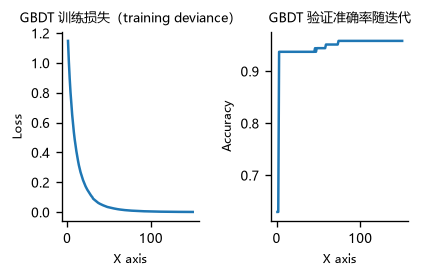

In [21]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

gb = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb.fit(Xtr, ytr)

train_loss = np.array(gb.train_score_)
staged_va = [accuracy_score(yv, p) for p in gb.staged_predict(Xv)]

fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].plot(np.arange(1, len(train_loss) + 1), train_loss)
ax[0].set_title("GBDT 训练损失（training deviance）")
ax[0].set_xlabel("X axis")
ax[0].set_ylabel("Loss")
ax[1].plot(np.arange(1, len(staged_va) + 1), staged_va)
ax[1].set_title("GBDT 验证准确率随迭代")
ax[1].set_xlabel("X axis")
ax[1].set_ylabel("Accuracy")
save_fig("20_gbdt")
display(fig)
plt.close(fig)


## 21. K-Means 聚类

无监督聚类问题：在没有标签的前提下，根据样本之间的相似性，将数据自动划分为若干组，使得同组内样本尽可能相似，不同组之间尽可能有差异。  K：预先指定的簇数。Means：均值，每个簇的中心位置由该簇内所有样本的均值来表示。
簇内相似度：通常通过簇内平方和 SSE来衡量（SSE越小，说明簇内样本越紧凑，聚类效果通常越好，样本点到质心的平方距离）：

$$
\sum_{i=1}^N \left\|x_i-\mu_{c_i}\right\|^2
$$

优化：

1、K-Means++:初始质心选择，先随机选取一个样本点作为第一个质心；之后，在选择下一个质心时候，优先考虑那些距离当前已有质心较远的样本点，重复这个过程，直到找到K个初始质心。
2、肘部法则选择K值：依次尝试不同的K值，计算对应的SSE；随着K值的增大，SSE会持续下降；当K超过某个值时，SSE下降明显减小，曲线趋于平缓；这个斜率突然减小、曲线由陡转平的拐点，就是较优的K值选择。

**优缺点**：
- 优点：实现简单、解释直观
- 缺点：需先定K、对初值敏感、倾向球形簇


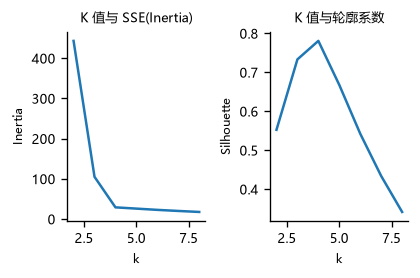

In [22]:
X, _ = make_blobs(n_samples=420, centers=4, cluster_std=1.1, random_state=42)
X = StandardScaler().fit_transform(X)
ks = np.arange(2, 9)
inertia = []
sil = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    if len(np.unique(labels)) > 1:
        sil.append(silhouette_score(X, labels))
    else:
        sil.append(np.nan)

k_best = ks[np.nanargmin(np.array(inertia))]
km = KMeans(n_clusters=k_best, random_state=42, n_init=10).fit(X)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].plot(ks, inertia)
ax[0].set_title("K 值与 SSE(Inertia)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sil)
ax[1].set_title("K 值与轮廓系数")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
save_fig("21_kmeans")
display(fig)
plt.close(fig)
